In [12]:
from datasets import Dataset, load_dataset
import json
#from huggingface_hub import HfApi, login
import pandas as pd
import numpy as np

In [14]:
dataset = load_dataset("thoughtworks/psychometrics_personas_temp")

In [15]:
df = dataset['train'].to_pandas()

In [16]:
df

,version,archetype,name,age,sex,location,education_level,bachelors_field,ethnic_background,marital_status,...,cognition,medical_developmental_history,family_history,educational_vocational_history,emotional_behavioral_functioning,social_functioning,summary_of_psychological_profile,concat_field,concat_embedding,uid
0,v6,The Problem Solver / Public Servant,Israel Velasco,49,Male,"Oak Lawn, IL",bachelors,stem_related,mexican,divorced,...,Sharp and methodical problem-solver; retains n...,Reports good general health without notable ch...,"Born to Mexican immigrant parents, raised with...",Holds a bachelor's degree in a STEM-related fi...,Manages community tensions with steady tempera...,Connects well with diverse local groups and pr...,"Israel demonstrates a thoughtful, community-or...",educational_vocational_history: Holds a bachel...,"[0.022095076739788003, -0.033202670514583005, ...",5d8d00c21cb40c3f210afc524a107f5944d72c1d470762...
1,v6,The Enforcer (Crime-Fighter),Herman Shepherd,42,Male,"Rochester, MN",graduate,arts_humanities,black,never_married,...,He demonstrates sharp recall for details relev...,"Generally robust physical health, with history...",Grew up as an only child in a working-class fa...,"Completed a graduate degree in humanities, app...","Under stress, he suppresses emotion and enhanc...","Prefers maintaining professional boundaries, e...",Herman exhibits strengths in situational contr...,educational_vocational_history: Completed a gr...,"[0.053143359720706, -0.060855995863676, -0.002...",bedd33f7b93c3e038cd481c0478aac0e7728717d5a9d77...
2,v6,The Tough Cop (Authoritarian),Justin Calloway,33,Male,"Candler, NC",some_college,no_degree,white,married_present,...,"Processes situations methodically, recalling d...",Healthy during development; no notable physica...,Married with stable household in Candler; rela...,Some college education with courses related to...,Handles occupational pressure with deliberate ...,Limited social engagement outside close family...,Justin embodies a firm commitment to order thr...,educational_vocational_history: Some college e...,"[0.10440348088741301, -0.08595354110002501, -0...",be005caaec844f14cbb05595476bfc907a9ba3ebac9fd0...
3,v6,The Problem Solver / Investigator,Marta Pedroza,56,Female,"Walla Walla, WA",graduate,education,mexican,divorced,...,Reflective and logically oriented thinking ena...,No significant physical health problems report...,Raised in a Mexican-American household in the ...,Completed bachelor’s degree in education and c...,Approaches emotional discomfort by tightening ...,Engages minimally with peers beyond required i...,Marta combines acute investigative intellect w...,educational_vocational_history: Completed bach...,"[0.060593824833631, -0.016584919765591, -0.006...",8655b7ae094aa851fb2041036fca0e9c6b39a956b9d77f...
4,v6,The Problem Solver / Investigator,Karen Criss,48,Female,"San Jose, CA",bachelors,business,white,married_present,...,Recalls facts methodically; organizes informat...,No significant medical concerns reported; expe...,Married to a supportive spouse with whom commu...,Obtained a bachelor's degree in business from ...,Tends to suppress outward emotional expression...,"Engages minimally in social exchanges at work,...","Karen presents as a highly disciplined, method...",educational_vocational_history: Obtained a bac...,"[0.047204926609992, -0.022000070661306003, -0....",f07680caff7046e509490f3e945db9a03b5806e65a74e0...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2568,v6,The Tough Cop (Authoritarian),Jerome Porter,30,Male,"Clarksville, TN",some_college,no_degree,black,married_present,...,Jerome recalls specific evidence and case deta...,No significant past health issues. Physical fi...,"Married, maintains steady familial relationshi...","Attended local college, completing coursework ...",Typically holds emotions tightly controlled du...,Engages with colleagues mainly within structur...,Jerome displays resilience f

In [20]:
from typing import Dict, List, Optional

def create_persona_narrative(row: pd.Series, 
                           sections: List[str] = None) -> str:
    """
    Combines selected persona sections into a natural narrative paragraph.
    
    Parameters:
    -----------
    row : pd.Series
        A row from the personas dataframe
    sections : List[str], optional
        List of column names to include. If None, uses default selection.
        
    Returns:
    --------
    str : Combined narrative text
    """
    
    # Default sections if none specified
    if sections is None:
        sections = [
            'archetype_description',
            'appearance', 
            'behavior',
            'mood_affect',
            'speech',
            'thought_content',
            'emotional_behavioral_functioning',
            'social_functioning'
        ]
    
    # Build the narrative
    narrative_parts = []
    
    # Enhanced intro with demographic info
    name = row.get('name', 'This person')
    age = row.get('age', '')
    sex = row.get('sex', '')
    location = row.get('location', '')
    education_level = row.get('education_level', '')
    ethnic_background = row.get('ethnic_background', '')
    marital_status = row.get('marital_status', '')
    
    intro = f"{name}"
    if age:
        intro += f", a {age}-year-old"
    if sex:
        intro += f" {sex.lower()}"
    if location:
        intro += f" from {location}"
    
    # Add demographic details if available
    demo_details = []
    if ethnic_background:
        demo_details.append(f"of {ethnic_background.replace('_', ' ').title()} background")
    if education_level:
        education_text = education_level.replace('_', ' ').title()
        if education_text == "Bachelors":
            education_text = "Bachelor's degree"
        demo_details.append(f"with a {education_text}")
    if marital_status and marital_status != 'unknown':
        demo_details.append(f"who is {marital_status}")
    
    if demo_details:
        intro += f", {', '.join(demo_details)},"
    else:
        intro += ","
    
    intro += " presents as someone who "
    
    narrative_parts.append(intro)
    
    # Process each section with natural transitions
    transitions = {
        'archetype_description': "",
        'appearance': "Physically, they ",
        'behavior': "In terms of behavior, they ",
        'mood_affect': "Their emotional presentation shows ",
        'speech': "When speaking, they demonstrate ",
        'thought_content': "Their thinking patterns reveal ",
        'insight_judgment': "They show ",
        'cognition': "Cognitively, they ",
        'emotional_behavioral_functioning': "Emotionally, they ",
        'social_functioning': "Socially, they ",
        'summary_of_psychological_profile': "Overall, ",
        'family_history': "Their background includes ",
        'educational_vocational_history': "Professionally, they ",
        'medical_developmental_history': "In terms of health and development, they "
    }
    
    for i, section in enumerate(sections):
        if section in row and pd.notna(row[section]) and str(row[section]).strip():
            content = str(row[section]).strip()
            
            # Add transition phrase
            if section in transitions:
                transition = transitions[section]
            else:
                transition = "Additionally, they "
            
            # Clean up the content to flow better
            content = content.replace('\n', ' ').replace('  ', ' ')
            
            # Make first letter lowercase if it follows a transition
            if transition and content:
                content = content[0].lower() + content[1:] if len(content) > 1 else content.lower()
            
            # Ensure proper sentence ending
            if content and not content.endswith(('.', '!', '?')):
                content += '.'
            
            narrative_parts.append(f"{transition}{content}")
    
    # Join all parts
    full_narrative = " ".join(narrative_parts)
    
    # Clean up any double spaces or formatting issues
    full_narrative = " ".join(full_narrative.split())
    
    return full_narrative

In [22]:
df['persona_narrative'] = df.apply(create_persona_narrative, axis=1)

In [24]:
df['persona_narrative'][0]

"Israel Velasco, a 49-year-old male from Oak Lawn, IL, of Mexican background, with a Bachelor's degree, who is divorced, presents as someone who Core trait: Long-term thinker focused on root causes and systemic improvement. Focus: Mediation, problem-solving, and connecting citizens to resources such as treatment or support services. Strengths: Invested in creating lasting community change rather than short-term fixes; May divert suspects toward mental health or substance abuse treatment instead of jail; Values departmental and cultural shifts toward community well-being; Fulfilled by forward-looking change at both individual and systemic levels. Challenges: Requires organizational support and sufficient time to be effective; Efforts can be undervalued in departments driven by short-term metrics like arrest counts; May struggle in results-oriented environments that prioritize quick wins over long-term improvement. Physically, they heavyset man with broad shoulders and solid, sturdy fram

In [26]:
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

def generate_embeddings(df: pd.DataFrame, 
                       text_column: str = 'persona_narrative',
                       model_name: str = "Qwen/Qwen3-Embedding-0.6B") -> np.ndarray:
    """
    Generates text embeddings for the specified column using sentence transformers.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing the text to embed
    text_column : str
        Name of the column containing text to embed
    model_name : str
        Name of the sentence transformer model to use
        
    Returns:
    --------
    np.ndarray : Array of embeddings with shape (n_samples, embedding_dim)
    """
    
    # Load the model
    model = SentenceTransformer(model_name)
    
    # Get the text data
    texts = df[text_column].fillna('').astype(str).tolist()
    
    # Generate embeddings
    embeddings = []
    for i in tqdm(range(len(df))):
        embedding = model.encode(texts[i], show_progress_bar=True)
        embeddings.append(embedding)
    
    return np.array(embeddings)

In [27]:
embeddings = generate_embeddings(df, 'persona_narrative')


  0%|                                                  | 0/2573 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|                                        | 1/2573 [00:01<1:21:40,  1.91s/it]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|                                          | 2/2573 [00:02<47:05,  1.10s/it]

...

100%|██████████████████████████████████████▉| 2571/2573 [20:28<00:00,  2.77it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████████████████████████████████▉| 2572/2573 [20:28<00:00,  2.70it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

100%|███████████████████████████████████████| 2573/2573 [20:29<00:00,  2.09it/s]


In [30]:
embeddings.shape

(2573, 1024)

In [34]:
df['concat_embedding'] = [embeddings[i] for i in range(2573)]

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap


def create_embedding_visualization_json(df: pd.DataFrame, 
                                       embedding_column: str = 'embedding',
                                       output_file: Optional[str] = None,
                                       include_columns: Optional[List[str]] = None,
                                       pca_components: int = 2,
                                       umap_components: int = 2,
                                       umap_params: Dict = None) -> Dict:
    """
    Creates a JSON structure with 2D PCA and UMAP transformations of embeddings
    along with all text columns from the dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with embeddings and text columns
    embedding_column : str
        Name of column containing embedding vectors
    output_file : str, optional
        If provided, saves JSON to this file
    include_columns : List[str], optional
        Specific columns to include. If None, includes all text columns
    pca_components : int
        Number of PCA components (default 2)
    umap_components : int  
        Number of UMAP components (default 2)
    umap_params : Dict, optional
        Additional UMAP parameters
        
    Returns:
    --------
    Dict : JSON-ready dictionary with embeddings and metadata
    """
    
    # Default UMAP parameters
    if umap_params is None:
        umap_params = {
            'n_neighbors': 15,
            'min_dist': 0.1,
            'metric': 'cosine',
            'random_state': 42
        }
    
    # Extract embeddings
    embeddings = np.array(df[embedding_column].tolist())
    
    # Standardize embeddings for better PCA results
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)
    
    # PCA transformation
    print("Performing PCA transformation...")
    pca = PCA(n_components=pca_components, random_state=42)
    pca_embeddings = pca.fit_transform(embeddings_scaled)
    
    # UMAP transformation
    print("Performing UMAP transformation...")
    umap_reducer = umap.UMAP(
        n_components=umap_components,
        **umap_params
    )
    umap_embeddings = umap_reducer.fit_transform(embeddings)
    
    # Determine which columns to include
    if include_columns is None:
        # Include all text/string columns and key numeric ones
        text_columns = []
        for col in df.columns:
            if col != embedding_column:  # Skip embedding column
                # Include if it's string type or important numeric columns
                if (df[col].dtype == 'object' or 
                    col in ['age', 'id', 'index'] or
                    df[col].dtype in ['int64', 'float64'] and col in ['age']):
                    text_columns.append(col)
        include_columns = text_columns
    
    # Build the JSON structure
    json_data = {
        "metadata": {
            "total_points": len(df),
            "original_embedding_dim": embeddings.shape[1],
            "pca_explained_variance_ratio": pca.explained_variance_ratio_.tolist(),
            "pca_total_variance_explained": float(pca.explained_variance_ratio_.sum()),
            "umap_parameters": umap_params,
            "included_columns": include_columns
        },
        "embeddings": {
            "pca": [],
            "umap": []
        },
        "data": []
    }
    
    # Process each data point
    print("Building JSON structure...")
    for i in range(len(df)):
        # PCA coordinates
        pca_point = {
            "x": float(pca_embeddings[i, 0]),
            "y": float(pca_embeddings[i, 1])
        }
        if pca_components > 2:
            for j in range(2, pca_components):
                pca_point[f"z{j-1}"] = float(pca_embeddings[i, j])
        
        # UMAP coordinates  
        umap_point = {
            "x": float(umap_embeddings[i, 0]),
            "y": float(umap_embeddings[i, 1])
        }
        if umap_components > 2:
            for j in range(2, umap_components):
                umap_point[f"z{j-1}"] = float(umap_embeddings[i, j])
        
        # Add to embeddings
        json_data["embeddings"]["pca"].append(pca_point)
        json_data["embeddings"]["umap"].append(umap_point)
        
        # Text and metadata for this point
        point_data = {"index": i}
        for col in include_columns:
            if col in df.columns:
                value = df.iloc[i][col]
                # Handle different data types
                if isinstance(value, (int, float, bool)):
                    point_data[col] = value
                elif isinstance(value, (list, dict, np.ndarray)):
                    point_data[col] = value if not isinstance(value, np.ndarray) else value.tolist()
                else:
                    point_data[col] = str(value)
        
        json_data["data"].append(point_data)

    print(json_data.keys())
    
    # Save to file if requested
    if output_file:
        print(f"Saving to {output_file}...")
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Created JSON with {len(df)} points")
    print(f"📊 PCA explained variance: {json_data['metadata']['pca_total_variance_explained']:.3f}")
    print(f"📋 Included {len(include_columns)} columns: {', '.join(include_columns[:5])}{'...' if len(include_columns) > 5 else ''}")
    
    return json_data, umap_embeddings

In [78]:
visualization_json, emb = create_embedding_visualization_json(
    df,
    embedding_column = 'concat_embedding',
    output_file='personas.json',
    umap_params = {'n_neighbors' : 10, 'min_dist' : 0.8}
)

Performing PCA transformation...
Performing UMAP transformation...
Building JSON structure...
dict_keys(['metadata', 'embeddings', 'data'])
Saving to personas.json...
✅ Created JSON with 2573 points
📊 PCA explained variance: 0.166
📋 Included 33 columns: version, archetype, name, age, sex...


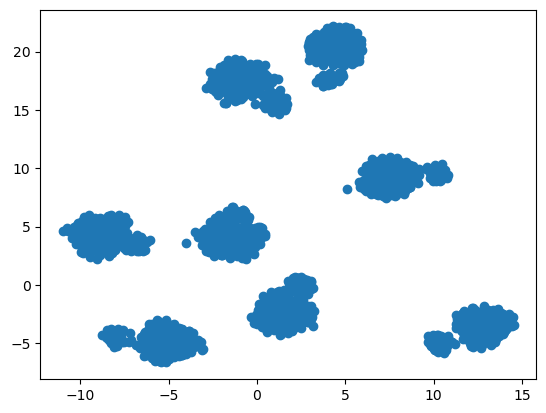

In [79]:

import matplotlib.pyplot as plt

plt.scatter(emb[:,0],emb[:,1])